Steps:
1) Type casting and renaming
3) Missing values (time, location)
4) Duplicates
5) Ilogical data: Extreme and negative
6) Outlier Filtering
7) Column cleanup
8) Time features
9) Other cleaning
10) Export

To run this notebook it is necessary to have the Taxi_Trip data downloaded as csv and names as "<i>Taxi_Trips_(2024-).csv.</i>"

## 0) Setup and data loading
First all necessary packages are imported, paths are setup and data is then loaded.

In [ ]:
QUICK_RUN = False
SUFFIX = "_mini" if QUICK_RUN else ""

import pandas as pd
import numpy as np
import polars as pl
import os
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

PROJECT = Path(os.getcwd()).parent
DATA_DIR = PROJECT / "data"

CSV_PATH = DATA_DIR / f"00/Taxi_Trips_(2024-){SUFFIX}.csv"

print("Setup complete.")
print(f"Project: {PROJECT}")
print(f"Data dir: {DATA_DIR}")

Setup complete.
Project: c:\Users\claus\AAA_project_team_5
Data dir: c:\Users\claus\AAA_project_team_5\data


In [4]:
data = pl.read_csv(CSV_PATH, low_memory=False, schema_overrides={"Trip Seconds": pl.String}) # do not remove casting to string!!!
original_rows = data.shape[0]
statistics = [("Original row count", original_rows)]
print(f"Loaded {data.shape[0]:,} rows, {data.shape[1]} columns")
print(f'DATA_DIR: {data.dtypes}')

print('Example columns:')
display(data.head(2))
data = data.lazy()

Loaded 15,406,960 rows, 23 columns
DATA_DIR: [String, String, String, String, String, String, Int64, Int64, Int64, Int64, String, String, String, String, String, String, String, String, String, String, String, String, String]
Example columns:


Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…","""05/01/2026 12:00:00 AM""","""05/01/2026 12:00:00 AM""","""398""","""1,16""",null,null,32,8,"""$6,75""","""$2,00""","""$0,00""","""$1,00""","""$10,25""","""Credit Card""","""Blue Ribbon Taxi Association""","""41,878865584""","""-87,625192142""","""POINT (-87.6251921424 41.87886…","""41,899602111""","""-87,633308037""","""POINT (-87.6333080367 41.89960…"
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…","""05/01/2026 12:00:00 AM""","""05/01/2026 12:15:00 AM""","""780""","""2""",null,null,8,28,"""$9,50""","""$4,00""","""$0,00""","""$2,00""","""$15,50""","""Credit Card""","""Transit Administrative Center …","""41,899602111""","""-87,633308037""","""POINT (-87.6333080367 41.89960…","""41,874005383""","""-87,66351755""","""POINT (-87.6635175498 41.87400…"


In [5]:
data.filter(
    pl.col('Pickup Centroid Longitude').is_null() & pl.col('Pickup Census Tract').is_null()
).collect().height

419331

# 1) Type casting and renaming
Next step is to convert the types to the correct data types as we can see above that not all columns are numeric.

In [6]:
# Casting
money_cols = ["Fare", "Tips", "Tolls", "Extras",  "Trip Total"]

data = data.with_columns(
    pl.col(money_cols)
    .str.replace("$", "", literal=True)
    .str.replace(",", ".", literal=True)
    .cast(pl.Float64, strict=False),
).with_columns( # Miles to float
    pl.col('Trip Miles').str.replace(",", ".", literal=True).cast(pl.Float64, strict=False),
    pl.col("Trip Seconds").str.replace(r"\.", "")
).with_columns( # timestamp casting
    pl.col("Trip Start Timestamp").str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias("Trip Start Timestamp"),
    pl.col("Trip End Timestamp").str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias("Trip End Timestamp"),
    (pl.col("Trip Seconds").cast(pl.Int64) * 1000).cast(pl.Duration("ms")).alias("Trip Seconds")    
). with_columns([
    pl.col("Pickup Centroid Latitude").str.replace(",", ".").cast(pl.Float64),
    pl.col("Pickup Centroid Longitude").str.replace(",", ".").cast(pl.Float64),
    pl.col("Dropoff Centroid Latitude").str.replace(",", ".").cast(pl.Float64),
    pl.col("Dropoff Centroid Longitude").str.replace(",", ".").cast(pl.Float64)]
).with_columns(
    pl.col("Pickup Census Tract").cast(pl.Int64, strict=False),
    pl.col("Dropoff Census Tract").cast(pl.Int64, strict=False)
).with_columns(    
    pl.col('Trip Start Timestamp').dt.replace_time_zone("America/Chicago", ambiguous="earliest").cast(pl.Datetime("ms", "America/Chicago")).alias('Trip Start Timestamp'),    
    pl.col('Trip End Timestamp').dt.replace_time_zone("America/Chicago", ambiguous="earliest").cast(pl.Datetime("ms", "America/Chicago")).alias('Trip End Timestamp')
    
)
    
data = data.collect()
display(data.head(2))

Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tips,Tolls,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,6m 38s,1.16,null,null,32,8,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…"
"""ec94d6d233061d415f0c89cb9222e9…","""b3ee94a13b61037620cbbfc6a4a106…",2026-05-01 00:00:00 CDT,2026-05-01 00:15:00 CDT,13m,2.0,null,null,8,28,9.5,4.0,0.0,2.0,15.5,"""Credit Card""","""Transit Administrative Center …",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…"


In [7]:
snake_map = {
    "Trip ID": "trip_id",
    "Taxi ID": "taxi_id",
    "Trip Start Timestamp": "trip_start",
    "Trip End Timestamp": "trip_end",
    "Trip Seconds": "trip_seconds",
    "Trip Miles": "trip_miles",
    "Pickup Census Tract": "pickup_census_tract",
    "Dropoff Census Tract": "dropoff_census_tract",
    "Pickup Community Area": "pickup_community_area",
    "Dropoff Community Area": "dropoff_community_area",
    "Fare": "fare_usd",
    "Tips": "tips_usd",
    "Tolls": "tolls_usd",
    "Extras": "extras_usd",
    "Trip Total": "trip_total_usd",
    "Payment Type": "payment_type",
    "Company": "company",
    "Pickup Centroid Latitude": "pickup_lat",
    "Pickup Centroid Longitude": "pickup_lon",
    "Pickup Centroid Location": "pickup_location",
    "Dropoff Centroid Latitude": "dropoff_lat",
    "Dropoff Centroid Longitude": "dropoff_lon",
    "Dropoff Centroid  Location": "dropoff_location",
}
# Polars: returns a new DataFrame, so reassign
data = data.rename(snake_map)

print(f"Renamed {len(snake_map)} columns.")
print(f'New column names: {data.columns}')

Renamed 23 columns.
New column names: ['trip_id', 'taxi_id', 'trip_start', 'trip_end', 'trip_seconds', 'trip_miles', 'pickup_census_tract', 'dropoff_census_tract', 'pickup_community_area', 'dropoff_community_area', 'fare_usd', 'tips_usd', 'tolls_usd', 'extras_usd', 'trip_total_usd', 'payment_type', 'company', 'pickup_lat', 'pickup_lon', 'pickup_location', 'dropoff_lat', 'dropoff_lon', 'dropoff_location']


# 3) Missing values
In this chapter missing values are handled.

In [8]:
print("Missing values by column:")
display(data.null_count())

Missing values by column:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,345,2936,146,8547337,8751654,429216,1366538,33658,31816,31830,31854,33707,0,0,421354,421354,421354,1285413,1285413,1285413


## 3.1) Missing time values
Missing time values can appear in trip_start, trip_end and trip_seconds.

We can see that the start time is always available but trip_end and trip seconds are incomplete. To note is the following information from the city of Chicago: <i>"Aggregation by time: all trips are rounded to the nearest 15-minute interval."</i> [Source](https://data.cityofchicago.org/stories/s/How-Chicago-Protects-Privacy-in-TNP-and-Taxi-Open-/82d7-i4i2/). This means that both, the trip_start and trip_end are not 100% exact and there is <b>no possibility to correct</b> this. 

In belows diagram you can see the difference between trip duration in seconds recalculated (trip_end-trip_start) and the provided trip duration. Second, is much more natural and shows a better distribution. Therefore, we take the trip_start as it is and use the trip duration to estimate trip_end.
While this does not ensure that trip_end is correct, it will provide us with more logical data as trip_seconds matches to the timestamps. 


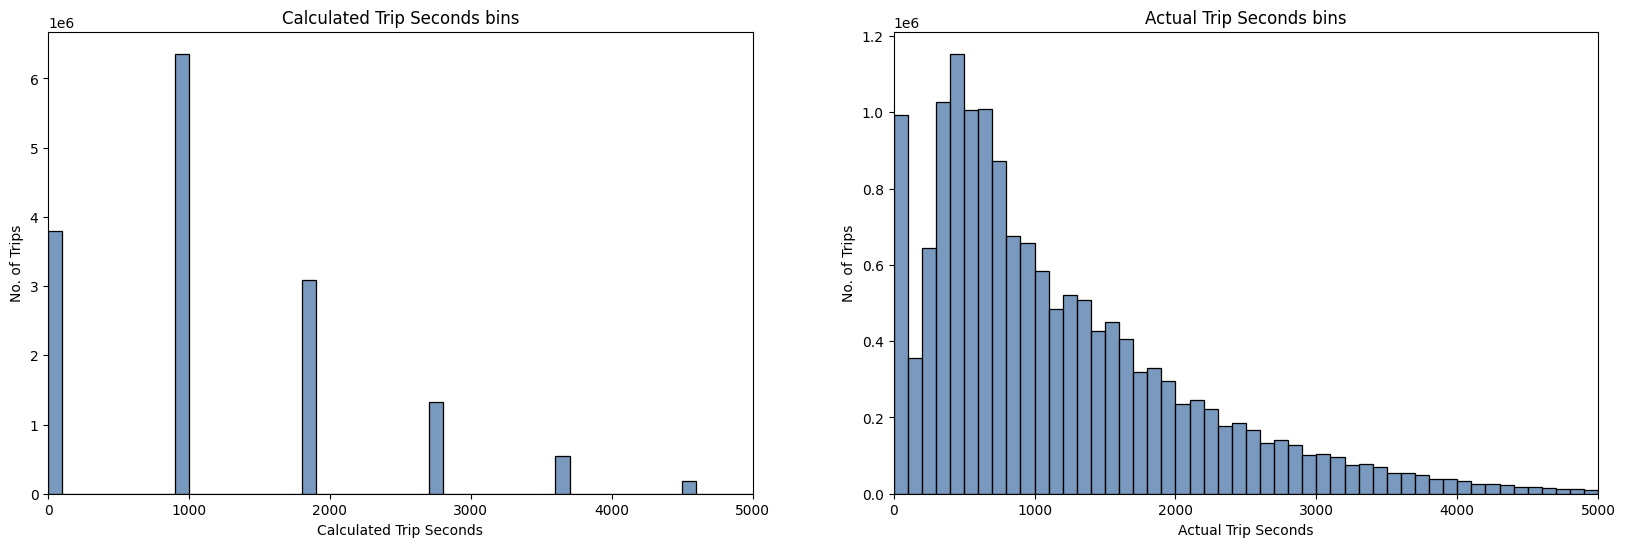

In [9]:
# distribution plot of calulated_trip_seconds
data = data.with_columns(
    (pl.col("trip_end") - pl.col("trip_start")).dt.total_seconds().alias("calculated_trip_seconds")
)
len(data)
fix, ax = plt.subplots(1, 2, figsize=(20, 6))
calculated_seconds = data.get_column("calculated_trip_seconds").drop_nulls().to_numpy()
actual_seconds = data.get_column("trip_seconds").dt.total_seconds().drop_nulls().to_numpy()

sns.histplot(calculated_seconds, bins=50, binrange=(0, 5000), ax=ax[0], color="#4C78A8", edgecolor="black")
ax[0].set_title("Calculated Trip Seconds bins")
ax[0].set_xlabel("Calculated Trip Seconds")
ax[0].set_ylabel("No. of Trips")
ax[0].set_xlim(0, 5000)

sns.histplot(actual_seconds, bins=50, binrange=(0, 5000), ax=ax[1], color="#4C78A8", edgecolor="black")
ax[1].set_title("Actual Trip Seconds bins")
ax[1].set_xlabel("Actual Trip Seconds")
ax[1].set_ylabel("No. of Trips")
ax[1].set_xlim(0, 5000)
plt.show()

Trip_end is recalculated based on trip_start and trip_seconds. There is a very low number of trip_seconds missing as seen be under 3), therefore we decided to just drop these. 

Afterwards trip_end is recalculated.

In [10]:
length = len(data)

data = data.filter(pl.col("trip_seconds").is_not_null())
print(f"Dropped {length - len(data):,} rows with missing trip_seconds.")
statistics.append(("Removed rows with missing trip_seconds", length - len(data)))

print('--' * 40)
print("Recalculating trip_end from trip_start and trip_seconds:")
print('\nBefore recalculation of trip_end:')
display(data.head(1))
data = data.with_columns(
        (pl.col("trip_start") + pl.col("trip_seconds").cast(pl.Duration("ms"))).alias("trip_end")
).drop("calculated_trip_seconds")
print('\nAfter recalculation of trip_end:')
display(data.head(1))

Dropped 2,936 rows with missing trip_seconds.
--------------------------------------------------------------------------------
Recalculating trip_end from trip_start and trip_seconds:

Before recalculation of trip_end:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,calculated_trip_seconds
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,i64
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00 CDT,2026-05-01 00:00:00 CDT,6m 38s,1.16,null,null,32,8,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…",0



After recalculation of trip_end:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str
"""f48c3b6c5c3bb929f585a167a9fd1f…","""85c39e068db414d181c6252a89fd82…",2026-05-01 00:00:00 CDT,2026-05-01 00:06:38 CDT,6m 38s,1.16,null,null,32,8,6.75,2.0,0.0,1.0,10.25,"""Credit Card""","""Blue Ribbon Taxi Association""",41.878866,-87.625192,"""POINT (-87.6251921424 41.87886…",41.899602,-87.633308,"""POINT (-87.6333080367 41.89960…"


## 3.2) Missing location values
Location values are all latitude, longitude, census tracts, locations, and community areas. 

These are especially important when trying to predict demand. According to the description of the city of Chicago, the location is either the center of the census tract or community area if there are too less trips out of the census tract. Therefore, the exact coordinates cannot be used to predict demand as they belong to the census tract or community area. 

Further we must assume that missing the census tract is due to privacy protection and therefore it cannot be interpolated. Even if we use the coordinates to interpolate the census tract, the records will be distributed in only certain census tracts which are the center of the community area. The census tracts around do not gain additional values.

> For the demand prediction the dropoff information are less important than the pickup. Therefore we keep all records which provide enough information about the pickup and ignore removing records with missing dropoff spatial information. The temporal spatial analysis will drop the data, while for the prediction model the columns are dropped. This way we ensure that both, analysis and prediction models have the most data available.


Still, the missing coordinates can be interpolated based on either the census tract or community area center. 

### 3.2.1) Pickup data
The records which have no spatial data about the pickup at all are not usable for the prediction of demand and it is impossible to interpolate these, hence they are dropped.

In [11]:
print("data length before spatial filtering: ", len(data))
location_cols = ["pickup_lat", "pickup_lon", "dropoff_lat", "dropoff_lon", "pickup_census_tract", "dropoff_census_tract", "pickup_community_area", "dropoff_community_area"]
print("Total rows with no spatial information about pickup: ", data.filter(
    pl.col("pickup_lat").is_null() &
    pl.col("pickup_lon").is_null() &
    pl.col("pickup_census_tract").is_null() &
    pl.col("pickup_community_area").is_null()
).shape[0])

length = len(data)
data = data.filter(
    ~(
        pl.col("pickup_lat").is_null() &
        pl.col("pickup_lon").is_null() &
        pl.col("pickup_census_tract").is_null() &
        pl.col("pickup_community_area").is_null()
    )
)

print(f"Dropped {length - len(data):,} rows with no spatial pickup information.")
statistics.append(("Removed rows with no spatial pickup information", length - len(data)))

print('\nRemaining rows with missing values in some location columns:')
display(data.select([pl.col(col).is_null().sum().alias(col) for col in location_cols]))

print("data length after spatial filtering: ", len(data))

data length before spatial filtering:  15404024
Total rows with no spatial information about pickup:  419093
Dropped 419,093 rows with no spatial pickup information.

Remaining rows with missing values in some location columns:


pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area
u32,u32,u32,u32,u32,u32,u32,u32
2015,2015,1005440,1005440,8126451,8359100,9862,1086058


data length after spatial filtering:  14984931


Remaining are around two thousand records which miss pickup coordinates. These records provide only the census track and not community area. Further, most of them do not match the available census tract information of the city of Chicago ([Source](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Census_Tracts/4hp8-2i8z/about_data)). Therefore, we assume that the available census tracts are outside of the city and we are able to drop these. The once which match are so few, that the additional overhead of imputing is not worth it, so all 2015 records are dropped.

In [12]:
location_cols_pickup = ["pickup_lat", "pickup_lon", "pickup_census_tract", "pickup_community_area"]
filtered_data = data.filter(
    pl.col("pickup_lat").is_null() |
    pl.col("pickup_lon").is_null())
print('\nRemaining rows with missing values in some location columns:')
display(filtered_data.select([pl.col(col).is_null().sum().alias(col) for col in location_cols_pickup]))

census_data = pl.read_csv("../data/00/Census_Tracts.csv")
# check if the census tracts with missing lat/lon are present in the census data
missing_tracts = filtered_data.select(pl.col("pickup_census_tract").unique())
print(f"Unique pickup census tracts with missing lat/lon: {missing_tracts.shape[0]}")
print(f"Census tracts which are missing lat/lon but present in census data of the city of chicago: {missing_tracts.join(census_data, left_on="pickup_census_tract", right_on="CENSUS_T_1", how="inner").drop_nulls('TRACT_CENT').shape[0]}")
print(f"Cencus tracts which are missing lat/lon and not present in census data of the city of chicago: {missing_tracts.join(census_data, left_on="pickup_census_tract", right_on="CENSUS_T_1", how="left").filter(pl.col("TRACT_CENT").is_null()).shape[0]}")

print(f"Records which could be imputed with census tract centroids: {filtered_data.join(census_data, left_on="pickup_census_tract", right_on="CENSUS_T_1", how="inner").drop_nulls('TRACT_CENT').shape[0]}")


length = len(data)
data = data.filter(
    ~(
        pl.col("pickup_lat").is_null() |
        pl.col("pickup_lon").is_null()
    )
)
print(f"Dropped {length - len(data):,} rows with missing pickup lat or lon.")
statistics.append(("Removed rows with missing pickup lat or lon with census data available", length - len(data)))


Remaining rows with missing values in some location columns:


pickup_lat,pickup_lon,pickup_census_tract,pickup_community_area
u32,u32,u32,u32
2015,2015,0,2015


Unique pickup census tracts with missing lat/lon: 215
Census tracts which are missing lat/lon but present in census data of the city of chicago: 5
Cencus tracts which are missing lat/lon and not present in census data of the city of chicago: 210
Records which could be imputed with census tract centroids: 121
Dropped 2,015 rows with missing pickup lat or lon.


In [13]:
print('\nRemaining rows with missing values in some location columns:')
display(data.select([pl.col(col).is_null().sum().alias(col) for col in location_cols]))


Remaining rows with missing values in some location columns:


pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area
u32,u32,u32,u32,u32,u32,u32,u32
0,0,1003535,1003535,8126451,8358930,7847,1084134


Generally, all records should have a community area, as this is not the case for a very low number of records: Records with missign pickup_community_area are also dropped. Records with missing pickup_census tract are not dropped yet as these are above half of the records. We to have the option to decide later between census tract and community scale prediction.

In [14]:
length = len(data)
data = data.filter((pl.col("pickup_community_area").is_not_null()))
print(f"Dropped {length - len(data):,} rows with missing pickup community area.")
statistics.append(("Removed rows with missing pickup community area", length - len(data)))

print('Percentage of records missing pickup_census_tract: ', (data.filter(pl.col("pickup_census_tract").is_null()).shape[0] / len(data)) * 100)

Dropped 7,847 rows with missing pickup community area.
Percentage of records missing pickup_census_tract:  54.2665345982713


### 3.2.2) Dropoff data
We do not remove the dropoff here yet. The columns are irrelevant for the prediction of demand, as there matters the pickup location, but it is relevant for the spatial temporal analysis.

In [15]:
print("Total rows with no spatial information about dropoff: ", data.filter(
    pl.col("dropoff_lat").is_null() &
    pl.col("dropoff_lon").is_null() &
    pl.col("dropoff_census_tract").is_null() &
    pl.col("dropoff_community_area").is_null()
).shape[0])


location_cols = ["pickup_lat", "pickup_lon", "dropoff_lat", "dropoff_lon", "pickup_census_tract", "dropoff_census_tract", "pickup_community_area", "dropoff_community_area"]
print("\nMissing values in location columns:")
display(data.select([pl.col(col).is_null().sum().alias(col) for col in location_cols]))

Total rows with no spatial information about dropoff:  988878

Missing values in location columns:


pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area
u32,u32,u32,u32,u32,u32,u32,u32
0,0,1003287,1003287,8126451,8358708,0,1077772


### 3.2.3) Trip distance
This metric has very low number of records. Similar to the dropoff this data can not really be used for the prediction models but it might be relevant for the spatial temporal analysis. Therefore the small number of records is dropped here.

In [16]:
print("Number of records missing trip_miles: ", data.filter(pl.col("trip_miles").is_null()).shape[0])

data = data.filter(pl.col("trip_miles").is_not_null())
print(f"Dropped {length - len(data):,} rows with missing trip_miles.")
statistics.append(("Removed rows with missing trip_miles", length - len(data)))

Number of records missing trip_miles:  118
Dropped 7,965 rows with missing trip_miles.


### 3.3) Other missing values
We can still see missing values in the money columns (fare_usd, tips_usd, extras_usd, trip_total_usd). These might be relevant for the spatial temporal analysis. Missing values are not dropped yet as these columns are most likely dropped entirely for the demand prediction. Still, same as the dropoff spatial information, they are kept here.

In [17]:
print("Missing values by column:")
display(data.null_count())

Missing values by column:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,8126377,8358634,0,1077766,31287,29936,29948,29970,31330,0,0,0,0,0,1003281,1003281,1003281


# 4) Duplicates
One taxi can only drive one trip at a time, so if combination of a taxi_id and a trip_start returns more than one record it is a duplicate.
Keeping in mind that the trip_starts are rounded to 15mins due to privacy reasons ([Source](https://data.cityofchicago.org/stories/s/How-Chicago-Protects-Privacy-in-TNP-and-Taxi-Open-/82d7-i4i2/)). It may be possible that two trips are in between a 15 min timeframe for one specific taxi. Example:<br>
taxi_1 can have a first trip at 14:55 ending at 15:01. Both timestamps are rounded to 15:00.<br>
A second trip can be from 15:01 to 15:07 and therefore could also be rounded. Both timestamps would be rounded to 15:00 too.

Still both trips happened in real life but we cannot guarantee that they are the same. We assume that trips that also start at different locations are distinct. For the demand prediction it is important to be as close as possible to the actual taxi trips. Therefore, we decided to keep the first records, assuming that at least one of the trips actual happened.


In [18]:
length_before = data.height
data = data.unique(subset=["taxi_id", 'trip_start', 'pickup_lon', 'pickup_lat'], keep="first")
length_removed = length_before - data.height
print(f"Removed {length_removed:,} rows with duplicate taxi_id, trip_start, pickup_lat, pickup_lon.")

Removed 213,151 rows with duplicate taxi_id, trip_start, pickup_lat, pickup_lon.


# 5) Ilogical data
In this part any values which do not make sense are removed.

## 5.1) Negative values
Starting with negative values in the following columns, as these do not make sense with a negative value:
`trip_seconds, trip_miles, fare_usd, tips_usd, tolls_usd, extras_usd, and trip_total_usd`

In [19]:
length = len(data)
print(f'Length before removing invalid records: {length:,}')
data = data.filter(
    (pl.col("trip_seconds") >= 0) &
    (pl.col("trip_miles") >= 0) &
    (pl.col("fare_usd") >= 0) &
    (pl.col("tips_usd") >= 0) &
    (pl.col("tolls_usd") >= 0) &
    (pl.col("extras_usd") >= 0) &
    (pl.col("trip_total_usd") >= 0)
)
print(f"Rows with negative trip_seconds, trip_miles, fare_usd, tips_usd, tolls_usd, extras_usd, and trip_total_usd removed: {length - len(data):,}")

print(f"\nRemaining after invalid trip removal: {len(data):,}")

Length before removing invalid records: 14,761,800


Rows with negative trip_seconds, trip_miles, fare_usd, tips_usd, tolls_usd, extras_usd, and trip_total_usd removed: 19,159

Remaining after invalid trip removal: 14,742,641


## 5.2) Extreme values
Extreme high or low value do not make sense depending on the column. 
1. Trips with less than 60 seconds duration are dropped because we assume these are too short. Also for the prediction these may be confusing, as the taxi is not actually occupied.
2. Trips with very short distances are also dropped because of the same reason above.
3. Trips with exactly zero fare are dropped. We assume that for our client, these trips are irrelevant as no money was earned.
4. Trips, where the <b>average</b> speed was over 100 mph (~160 km/h)

In [20]:
length = len(data)
data = data
data = data.filter(
    (pl.col('trip_seconds') > (60*1000)) & 
    (pl.col('trip_miles') > 0.01) & 
    (pl.col('fare_usd') > 0)
)
print(f"Rows removed (reason 1, 2, and 3): {length - len(data):,}")

data = data.with_columns(
    (pl.col("trip_miles") / (pl.col("trip_seconds").cast(pl.Float64) / 3_600_000)).alias("average_speed_mph")
).filter(pl.col('average_speed_mph') < 100)
print(f"Rows with implausible average speed (>100 mph) removed: {length - len(data):,}")

print(f"\nRemaining after removing extreme values: {len(data):,}")
statistics.append(("Removed extreme values", length - len(data)))

Rows removed (reason 1, 2, and 3): 1,251,942
Rows with implausible average speed (>100 mph) removed: 1,253,024

Remaining after removing extreme values: 13,489,617


In [21]:
data.head(3)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,average_speed_mph
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,f64
"""f9df87eafdfde004d367410e456563…","""9b6a972a0eeaf8e76ab0192dfe37d0…",2026-04-09 09:00:00 CDT,2026-04-09 09:27:00 CDT,27m,5.8,null,null,38,28,20.5,0.0,0.0,0.0,20.5,"""Unknown""","""Transit Administrative Center …",41.812949,-87.61786,"""POINT (-87.6178596758 41.81294…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…",12.888889
"""f0ebda39ef05e13d5e869bee2012e9…","""fa291651bedb0cd9f16d0c71824e90…",2026-03-08 17:15:00 CDT,2026-03-08 17:55:17 CDT,40m 17s,21.3,null,null,76,35,51.5,14.25,0.0,5.0,71.25,"""Mobile""","""Flash Cab""",41.980264,-87.913625,"""POINT (-87.913624596 41.980264…",41.835118,-87.618678,"""POINT (-87.6186777673 41.83511…",31.725279
"""439075dd54c04bab1698cc95e57134…","""e8b60c43eaaae4c1bad2c23e45e93a…",2024-11-11 21:30:00 CST,2024-11-11 21:49:29 CST,19m 29s,10.84,17031980100,17031320400,56,32,45.0,9.1,0.0,0.0,54.6,"""Credit Card""","""Sun Taxi""",41.785999,-87.750934,"""POINT (-87.7509342894 41.78599…",41.877406,-87.621972,"""POINT (-87.6219716519 41.87740…",33.382378


# 6) Outlier Filtering
Below diagram shows the distribution of trip_seconds, trip_miles and fare. 

Extreme long trips of mouch more than 17 miles are only very few. Further the trip duration is usually below 1 hour. Also the fare is below 70 US$. 

We decided to only remove trips which are extordinary long. This means trips taking over 12 hours and over 200 miles.

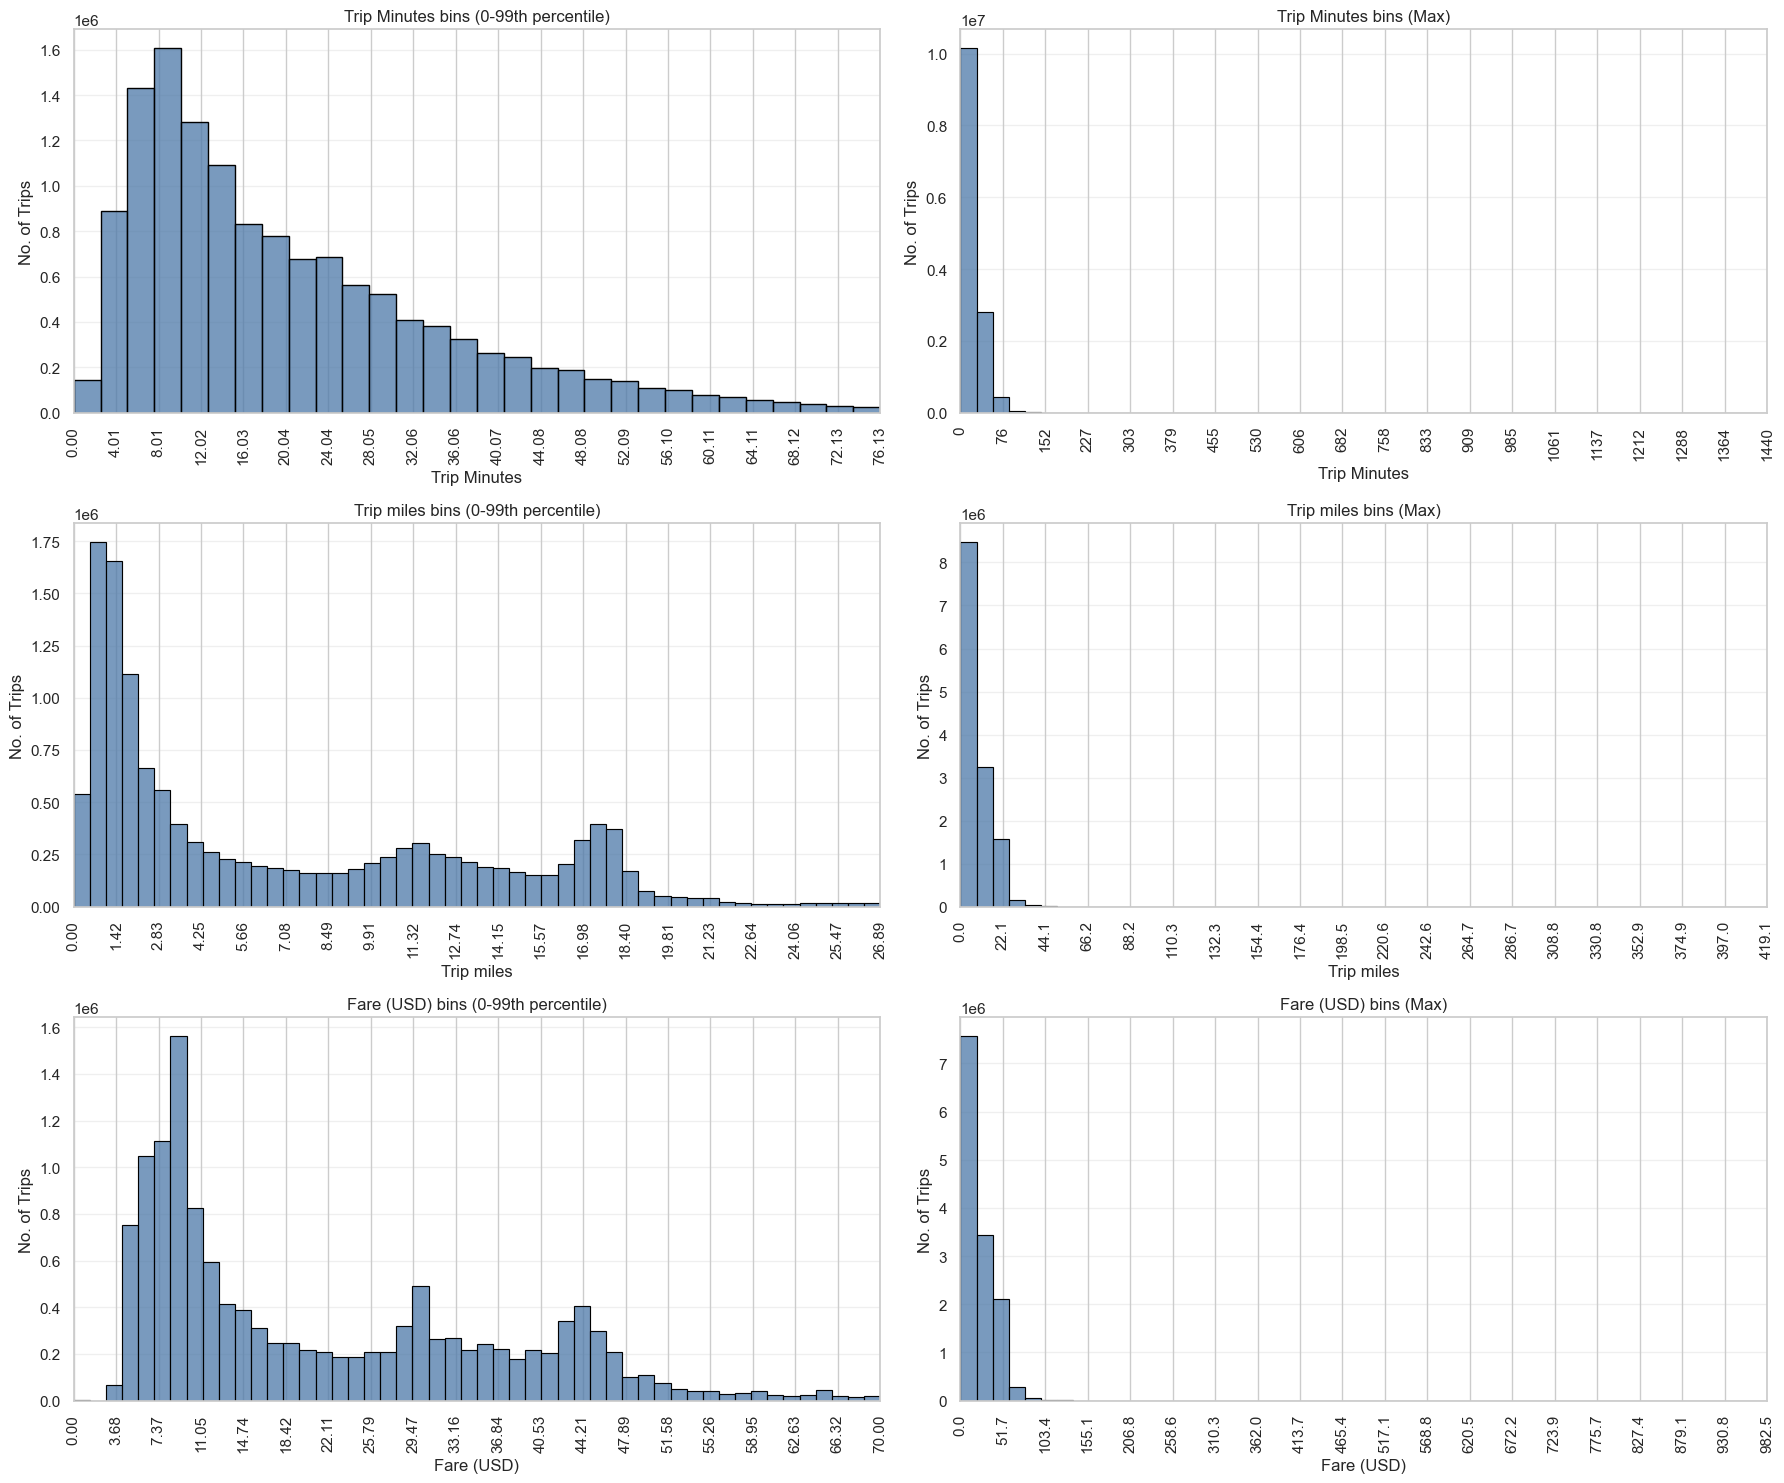

In [ ]:
#| label: fig-outlier-filtering
#| fig-cap: "Distribution of trip counts compared to the 99th percentile and maximum values for trip duration, trip miles, and fare."
plot_df = data.select(["trip_seconds", "trip_miles", "fare_usd"])
plot_df = plot_df.with_columns([
    (pl.col("trip_seconds").dt.total_seconds()/60).alias("trip_seconds"),
])


num_ticks = 20
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# --- 1. TRIP SECONDS ---
trip_seconds = plot_df.get_column("trip_seconds").drop_nulls().to_numpy()
trip_seconds_pct = float(np.quantile(trip_seconds, 0.99))
trip_seconds_max = float(trip_seconds.max())

# Left Plot (Percentile)
sns.histplot(
    trip_seconds,
    bins=30,
    binrange=(0, trip_seconds_pct),
    ax=axes[0, 0],
    color="#4C78A8",
    edgecolor="black",
)
axes[0, 0].set_title("Trip Minutes bins (0-99th percentile)")
axes[0, 0].set_xlabel("Trip Minutes")
axes[0, 0].set_ylabel("No. of Trips")
axes[0, 0].set_xlim(0, trip_seconds_pct)
axes[0, 0].set_xticks(np.linspace(0, trip_seconds_pct, num_ticks))
axes[0, 0].tick_params(axis="x", rotation=90)
axes[0, 0].grid(axis="y", alpha=0.3)

# Right Plot (Max)
sns.histplot(
    trip_seconds,
    bins=50,
    binrange=(0, trip_seconds_max),
    ax=axes[0, 1],
    color="#4C78A8",
    edgecolor="black",
)
axes[0, 1].set_title("Trip Minutes bins (Max)")
axes[0, 1].set_xlabel("Trip Minutes")
axes[0, 1].set_ylabel("No. of Trips")
axes[0, 1].set_xlim(0, trip_seconds_max)
axes[0, 1].set_xticks(np.linspace(0, trip_seconds_max, num_ticks))
axes[0, 1].tick_params(axis="x", rotation=90)
axes[0, 1].grid(axis="y", alpha=0.3)


# --- 2. TRIP MILES ---
trip_miles = plot_df.get_column("trip_miles").drop_nulls().to_numpy()
trip_miles_pct = float(np.quantile(trip_miles, 0.99))
trip_miles_max = float(trip_miles.max())

# Left Plot (Percentile)
sns.histplot(
    trip_miles,
    bins=50,
    binrange=(0, trip_miles_pct),
    ax=axes[1, 0],
    color="#4C78A8",
    edgecolor="black",
)
axes[1, 0].set_title("Trip miles bins (0-99th percentile)")
axes[1, 0].set_xlabel("Trip miles")
axes[1, 0].set_ylabel("No. of Trips")
axes[1, 0].set_xlim(0, trip_miles_pct)
axes[1, 0].set_xticks(np.linspace(0, trip_miles_pct, num_ticks))
axes[1, 0].tick_params(axis="x", rotation=90)
axes[1, 0].grid(axis="y", alpha=0.3)

# Right Plot (Max)
sns.histplot(
    trip_miles,
    bins=50,
    binrange=(0, trip_miles_max),
    ax=axes[1, 1],
    color="#4C78A8",
    edgecolor="black",
)
axes[1, 1].set_title("Trip miles bins (Max)")
axes[1, 1].set_xlabel("Trip miles")
axes[1, 1].set_ylabel("No. of Trips")
axes[1, 1].set_xlim(0, trip_miles_max)
axes[1, 1].set_xticks(np.linspace(0, trip_miles_max, num_ticks))
axes[1, 1].tick_params(axis="x", rotation=90)
axes[1, 1].grid(axis="y", alpha=0.3)


# --- 3. FARE USD ---
fare_usd = plot_df.get_column("fare_usd").drop_nulls().to_numpy()
fare_usd_pct = float(np.quantile(fare_usd, 0.99))
fare_usd_max = float(fare_usd.max())

# Left Plot (Percentile)
sns.histplot(
    fare_usd,
    bins=50,
    binrange=(0, fare_usd_pct),
    ax=axes[2, 0],
    color="#4C78A8",
    edgecolor="black",
)
axes[2, 0].set_title("Fare (USD) bins (0-99th percentile)")
axes[2, 0].set_xlabel("Fare (USD)")
axes[2, 0].set_ylabel("No. of Trips")
axes[2, 0].set_xlim(0, fare_usd_pct)
axes[2, 0].set_xticks(np.linspace(0, fare_usd_pct, num_ticks))
axes[2, 0].tick_params(axis="x", rotation=90)
axes[2, 0].grid(axis="y", alpha=0.3)

# Right Plot (Max)
sns.histplot(
    fare_usd,
    bins=50,
    binrange=(0, fare_usd_max),
    ax=axes[2, 1],
    color="#4C78A8",
    edgecolor="black",
)
axes[2, 1].set_title("Fare (USD) bins (Max)")
axes[2, 1].set_xlabel("Fare (USD)")
axes[2, 1].set_ylabel("No. of Trips")
axes[2, 1].set_xlim(0, fare_usd_max)
axes[2, 1].set_xticks(np.linspace(0, fare_usd_max, num_ticks))
axes[2, 1].tick_params(axis="x", rotation=90)
axes[2, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
length = len(data)

data = data.filter((pl.col('trip_miles') < 200) & (pl.col('trip_seconds') < 3*60*60*1000))

print(f"Rows removed with trip_miles < 200 and trip_seconds < 3 hours: {length - len(data):,}")
statistics.append(("Removed rows with trip_miles < 200 and trip_seconds < 3 hours", length - len(data)))

Rows removed with trip_miles < 200 and trip_seconds < 3 hours: 11,325


In [24]:
data.head(1)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,average_speed_mph
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,f64
"""f9df87eafdfde004d367410e456563…","""9b6a972a0eeaf8e76ab0192dfe37d0…",2026-04-09 09:00:00 CDT,2026-04-09 09:27:00 CDT,27m,5.8,null,null,38,28,20.5,0.0,0.0,0.0,20.5,"""Unknown""","""Transit Administrative Center …",41.812949,-87.61786,"""POINT (-87.6178596758 41.81294…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…",12.888889


# 7) Column cleanup
## 7.1) Column: Payment Type
Cleanup the payment type column

Payment types: 7


payment_type,count
str,u32
"""unknown""",487669
"""prcard""",1627916
"""cash""",2932539
"""credit card""",4995508
"""dispute""",4533
"""mobile""",3407776
"""no charge""",22351


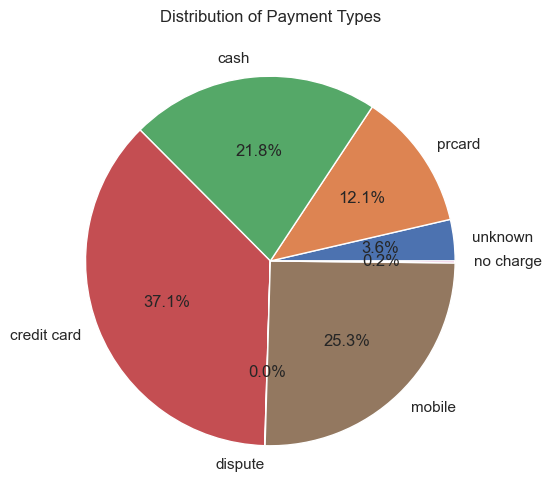

In [25]:
data = data.with_columns(
    pl.col("payment_type")
    .str.to_lowercase()
    .str.strip_chars()
    .str.replace_all(r"\s+", " ", literal=False)
)

# 2. Print unique count
print(f"Payment types: {data['payment_type'].n_unique()}")

# 3. Print value counts
vc = data["payment_type"].value_counts()
display(vc)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")
ax.pie(vc["count"], labels=vc["payment_type"], autopct='%1.1f%%')
plt.title("Distribution of Payment Types")
plt.show()

## 7.2) Column: Company 
Cleanup the company column

Unique companies: 38


company,count
str,u32
"""flash cab""",2812468
"""taxicab insurance agency llc""",1823908
"""sun taxi""",1567406
"""city service""",1421394
"""taxi affiliation services""",1305373
…,…
"""4053 - 40193 adwar h nikola""",1673
"""petani cab corp""",1060
"""taxi affiliation services llc …",1012


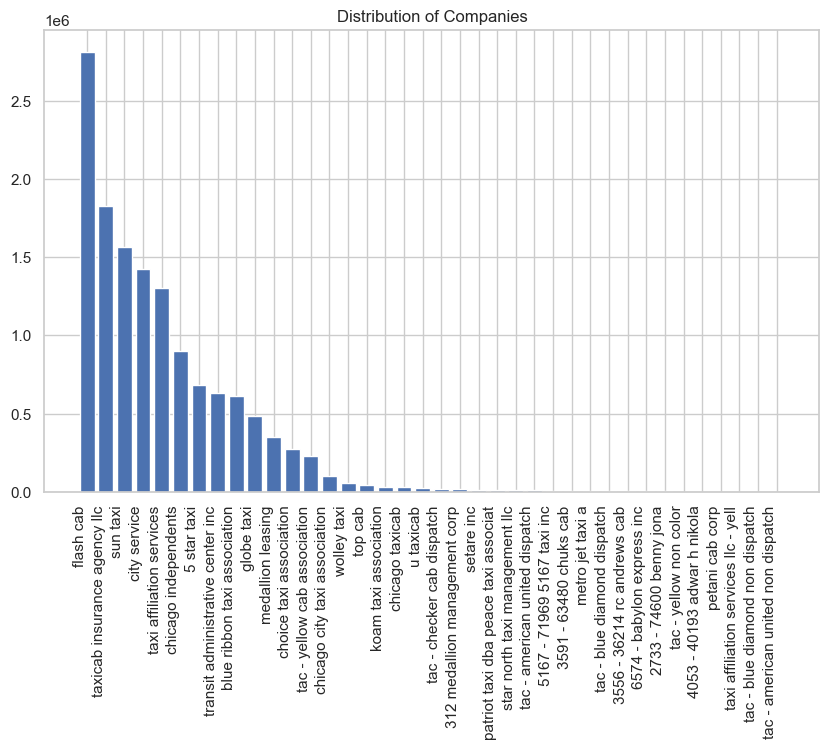

In [26]:
data = data.with_columns(
    pl.col("company")
    .str.to_lowercase()
    .str.strip_chars()
    .str.replace_all(r"\s+", " ", literal=False)
    .str.replace_all(r"[,\.]", "", literal=False)
)

# 2. Map the manual replacements
manual_mappings = {
    "choice taxi association inc": "choice taxi association",
    "blue ribbon taxi association inc": "blue ribbon taxi association",
    "top cab affiliation": "top cab",
    "medallion leasin": "medallion leasing",
}
data = data.with_columns(
    pl.col("company").replace(manual_mappings)
)

print(f"Unique companies: {data['company'].n_unique()}")

vc = data["company"].value_counts().sort("count", descending=True)
display(vc)

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style("whitegrid")
ax.bar(vc['company'], vc["count"])
plt.xticks(rotation=90, ha='right')
plt.title("Distribution of Companies")
plt.show()

# 8) Time features
For later usage we already define additional features here.

In [27]:
data = data.with_columns(
    pl.col("trip_start").dt.hour().cast(pl.Int8).alias("hour"),
    pl.col("trip_start").dt.weekday().cast(pl.Int8).alias("day_of_week"), # Polars Monday=1, Sunday=7 -> shift to 0-6
    pl.col("trip_start").dt.month().cast(pl.Int8).alias("month"),
    pl.col("trip_start").dt.date().alias("date")
).with_columns(    
    pl.col("day_of_week").is_in([6, 7]).alias("is_weekend"), # 6= Saturday, 7= Sunday
    pl.col("trip_start").dt.truncate("30m").alias("bin_30min"),
    pl.col("trip_start").dt.truncate("1h").alias("bin_1h"),
    pl.col("trip_start").dt.truncate("4h").alias("bin_4h"),
    pl.col("trip_start").dt.truncate("1d").alias("bin_1d"),
    pl.col("trip_start").dt.truncate("1w").alias("bin_1w"),
)

time_cols = ["trip_start", "hour", "day_of_week", "month", "date", "is_weekend",
             "bin_30min", "bin_1h", "bin_4h", "bin_1d", "bin_1w"]

print(f"Added {len(time_cols)} time columns.")

# Select columns and sample
display((data.select(time_cols).sample(n=10, seed=42)))

Added 11 time columns.


trip_start,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w
"datetime[ms, America/Chicago]",i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]"
2025-11-21 12:00:00 CST,12,5,11,2025-11-21,false,2025-11-21 12:00:00 CST,2025-11-21 12:00:00 CST,2025-11-21 12:00:00 CST,2025-11-21 00:00:00 CST,2025-11-17 00:00:00 CST
2024-09-01 05:45:00 CDT,5,7,9,2024-09-01,true,2024-09-01 05:30:00 CDT,2024-09-01 05:00:00 CDT,2024-09-01 04:00:00 CDT,2024-09-01 00:00:00 CDT,2024-08-26 00:00:00 CDT
2024-02-17 20:30:00 CST,20,6,2,2024-02-17,true,2024-02-17 20:30:00 CST,2024-02-17 20:00:00 CST,2024-02-17 20:00:00 CST,2024-02-17 00:00:00 CST,2024-02-12 00:00:00 CST
2024-10-17 12:45:00 CDT,12,4,10,2024-10-17,false,2024-10-17 12:30:00 CDT,2024-10-17 12:00:00 CDT,2024-10-17 12:00:00 CDT,2024-10-17 00:00:00 CDT,2024-10-14 00:00:00 CDT
2025-11-17 11:30:00 CST,11,1,11,2025-11-17,false,2025-11-17 11:30:00 CST,2025-11-17 11:00:00 CST,2025-11-17 08:00:00 CST,2025-11-17 00:00:00 CST,2025-11-17 00:00:00 CST
2024-12-08 16:45:00 CST,16,7,12,2024-12-08,true,2024-12-08 16:30:00 CST,2024-12-08 16:00:00 CST,2024-12-08 16:00:00 CST,2024-12-08 00:00:00 CST,2024-12-02 00:00:00 CST
2025-06-01 00:00:00 CDT,0,7,6,2025-06-01,true,2025-06-01 00:00:00 CDT,2025-06-01 00:00:00 CDT,2025-06-01 00:00:00 CDT,2025-06-01 00:00:00 CDT,2025-05-26 00:00:00 CDT
2024-10-22 06:45:00 CDT,6,2,10,2024-10-22,false,2024-10-22 06:30:00 CDT,2024-10-22 06:00:00 CDT,2024-10-22 04:00:00 CDT,2024-10-22 00:00:00 CDT,2024-10-21 00:00:00 CDT
2024-10-03 20:45:00 CDT,20,4,10,2024-10-03,false,2024-10-03 20:30:00 CDT,2024-10-03 20:00:00 CDT,2024-10-03 20:00:00 CDT,2024-10-03 00:00:00 CDT,2024-09-30 00:00:00 CDT


# 9) Rest
Here are all other required operations stored.

In [29]:
data.head(1)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,pickup_location,dropoff_lat,dropoff_lon,dropoff_location,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,str,f64,f64,str,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]"
"""f9df87eafdfde004d367410e456563…","""9b6a972a0eeaf8e76ab0192dfe37d0…",2026-04-09 09:00:00 CDT,2026-04-09 09:27:00 CDT,27m,5.8,null,null,38,28,20.5,0.0,0.0,0.0,20.5,"""unknown""","""transit administrative center …",41.812949,-87.61786,"""POINT (-87.6178596758 41.81294…",41.874005,-87.663518,"""POINT (-87.6635175498 41.87400…",12.888889,9,4,4,2026-04-09,false,2026-04-09 09:00:00 CDT,2026-04-09 09:00:00 CDT,2026-04-09 08:00:00 CDT,2026-04-09 00:00:00 CDT,2026-04-06 00:00:00 CDT


In [30]:
# Drop columns which are duplicate
data = data.drop('pickup_location', 'dropoff_location')
data.head(1)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]"
"""f9df87eafdfde004d367410e456563…","""9b6a972a0eeaf8e76ab0192dfe37d0…",2026-04-09 09:00:00 CDT,2026-04-09 09:27:00 CDT,27m,5.8,null,null,38,28,20.5,0.0,0.0,0.0,20.5,"""unknown""","""transit administrative center …",41.812949,-87.61786,41.874005,-87.663518,12.888889,9,4,4,2026-04-09,false,2026-04-09 09:00:00 CDT,2026-04-09 09:00:00 CDT,2026-04-09 08:00:00 CDT,2026-04-09 00:00:00 CDT,2026-04-06 00:00:00 CDT


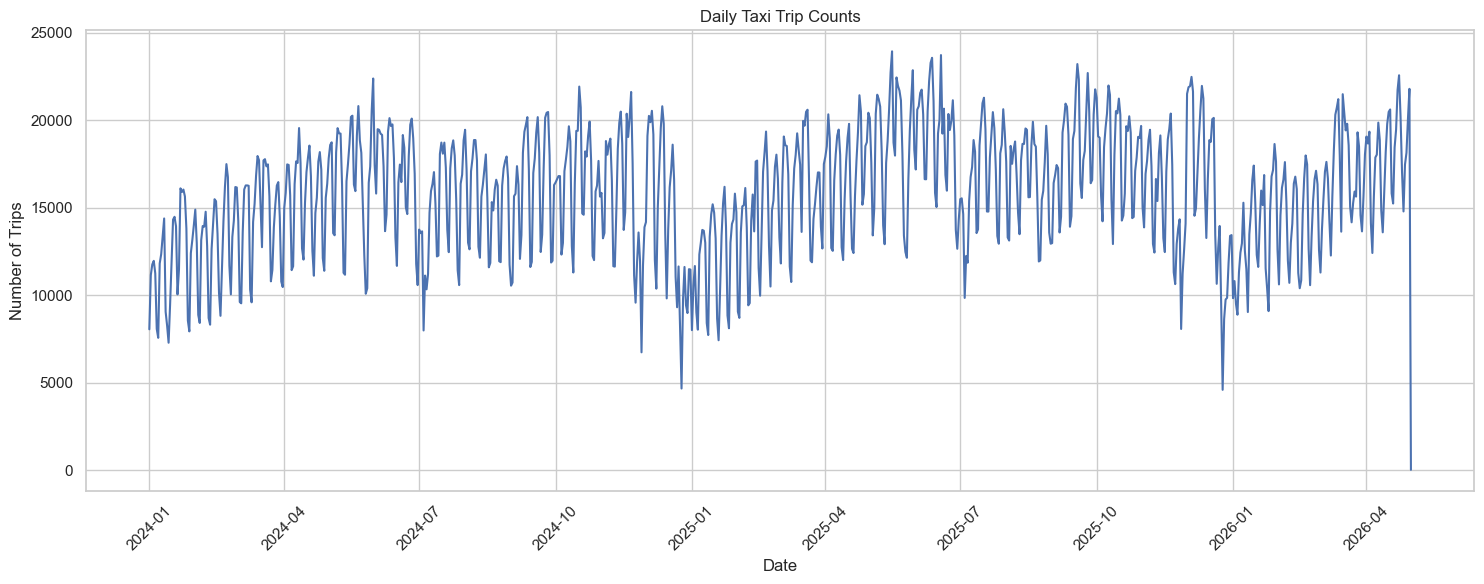

In [31]:

data = data.with_columns(pl.col("date").cast(pl.Date))
daily_counts = data.group_by("date").agg(pl.count("trip_id").alias("trip_count"))
daily_counts = daily_counts.sort("date")
plt.figure(figsize=(15, 6))
sns.lineplot(x="date", y="trip_count", data=daily_counts.to_pandas())
plt.title("Daily Taxi Trip Counts")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
missing_days = daily_counts.filter(pl.col("trip_count") == 0)
print(f"Days with no taxi trips: {missing_days.shape[0]}")
display(missing_days)

Days with no taxi trips: 0


date,trip_count
date,u32


# 10) Export

In [33]:
for stat in statistics:
    print(f"{stat[0]}: {stat[1]:,}")
print('Remaining rows after all cleaning steps: {:,}'.format(len(data)))

Original row count: 15,406,960
Removed rows with missing trip_seconds: 2,936
Removed rows with no spatial pickup information: 419,093
Removed rows with missing pickup lat or lon with census data available: 2,015
Removed rows with missing pickup community area: 7,847
Removed rows with missing trip_miles: 7,965
Removed extreme values: 1,253,024
Removed rows with trip_miles < 200 and trip_seconds < 3 hours: 11,325
Remaining rows after all cleaning steps: 13,478,292


In [34]:
data.write_parquet(f'../data/01/01_cleaned_data{SUFFIX}.parquet')